# 04 · Diagnosis demo: from a driving log to a report

**Question:** what does the analyzer actually do with a driving log, step by step, and what does a user get back?

This notebook needs **no downloads**: it uses the sample trips in `data/samples/` and the trained model in `models/`, so it runs right after cloning the repository.

**Contents**
1. The input
2. Step by step: clean → score → anomaly episodes → root cause → link fault codes → health score
3. The finished report
4. All sample trips
5. Same trip, different inputs (fault code with time, without time, none)
6. Missing signals
7. Accuracy at scale
8. Summary

In [1]:
import sys
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "analyzer").exists())
sys.path.insert(0, str(ROOT / "src"))

from analyzer.analysis.correlation import episode_evidence, find_episodes, infer_root_cause, link_dtcs
from analyzer.analysis.diagnosis import diagnose
from analyzer.analysis.health_score import DTC_PENALTY
from analyzer.detection.anomaly import AnomalyDetector
from analyzer.ingestion.cleaner import clean_trip_log
from analyzer.ingestion.loader import load_trip_log
from analyzer.pipeline import DEFAULT_MODEL_PATH, collect_dtcs, run

BLUE, MUTED = "#2a78d6", "#a3a29d"
FAULT_SHADE = "#d03b3b"
STATUS_COLORS = {"good": "#0ca30c", "needs attention": "#fab219", "critical": "#d03b3b"}
TEXT, TEXT_2, GRID = "#0b0b0b", "#52514e", "#e8e7e3"
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GRID, "axes.labelcolor": TEXT_2, "axes.titlecolor": TEXT,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": TEXT_2, "ytick.color": TEXT_2, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "lines.linewidth": 2, "legend.frameon": False, "font.size": 10,
})
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_colwidth", 80)

SAMPLES = ROOT / "data" / "samples"
detector = AnomalyDetector.load(DEFAULT_MODEL_PATH)
print("model loaded:", ", ".join(detector.models), "detectors")

model loaded: engine, speed, fuel, air, battery detectors


## 1. The input

A driving log is a CSV with one row per reading (about one per second). Only `time_ms`, `speed_kmh` and `engine_rpm` are required; the other signals are optional. Fault codes read from the car can be added separately.

This demo uses `vacuum_leak.csv`: a real VED trip with a simulated vacuum leak, and the fault code it set.

In [2]:
log_path, dtc_path = SAMPLES / "vacuum_leak.csv", SAMPLES / "vacuum_leak_dtc.csv"
raw = pd.read_csv(log_path)
print(f"{len(raw)} readings, {raw['time_ms'].max() / 60_000:.1f} minutes")
print("fault codes file:")
print(pd.read_csv(dtc_path).to_string(index=False))
raw.head()

824 readings, 11.3 minutes
fault codes file:
 code  time_ms
P0171   478000


,vehicle_id,trip_id,timestamp,time_ms,speed_kmh,engine_rpm,maf_gs,absolute_load_pct,stft_b1_pct,ltft_b1_pct,stft_b2_pct,ltft_b2_pct,hv_battery_voltage_v,hv_battery_current_a,hv_battery_soc_pct
0,347,1891,2017-11-04 16:28:08.260,0,35.00,"1,632.00",35.39,50.98,0.00,-1.56,0.00,-3.12,NaN,NaN,NaN
1,347,1891,2017-11-04 16:28:08.960,700,42.00,"1,632.00",35.39,50.98,0.00,-1.56,0.00,-3.12,NaN,NaN,NaN
2,347,1891,2017-11-04 16:28:09.760,1500,42.00,"1,824.00",39.96,67.06,0.00,-1.56,0.00,-3.12,NaN,NaN,NaN
3,347,1891,2017-11-04 16:28:09.960,1700,45.00,"1,824.00",39.96,67.06,0.00,-1.56,0.00,-3.12,NaN,NaN,NaN
4,347,1891,2017-11-04 16:28:10.760,2500,45.00,"1,824.00",39.96,67.06,4.69,-1.56,5.47,-3.12,NaN,NaN,NaN


## 2. Step by step

`analyzer.pipeline.run()` does all of this in one call; here each step is run separately to show what it produces.

### 2a. Load and clean

In [3]:
logs = clean_trip_log(load_trip_log(log_path))
events = collect_dtcs(logs, dtc_file=dtc_path)
present = [c for c in ["speed_kmh", "engine_rpm", "maf_gs", "absolute_load_pct", "stft_b1_pct", "ltft_b1_pct",
                       "hv_battery_voltage_v"] if logs[c].notna().any()]
print(f"clean readings: {len(logs)} | signals present: {', '.join(present)}")
events

clean readings: 824 | signals present: speed_kmh, engine_rpm, maf_gs, absolute_load_pct, stft_b1_pct, ltft_b1_pct


,vehicle_id,trip_id,time_ms,code,time_known
0,347,1891,478000,P0171,True


### 2b. Score every reading

Each subsystem detector gives a score per reading (1.0 = edge of normal behaviour). The overall score is the highest one, and an alarm is raised once 70% of the last 30 readings are anomalous.

first alarm at 7.68 min, P0171 set at 7.97 min


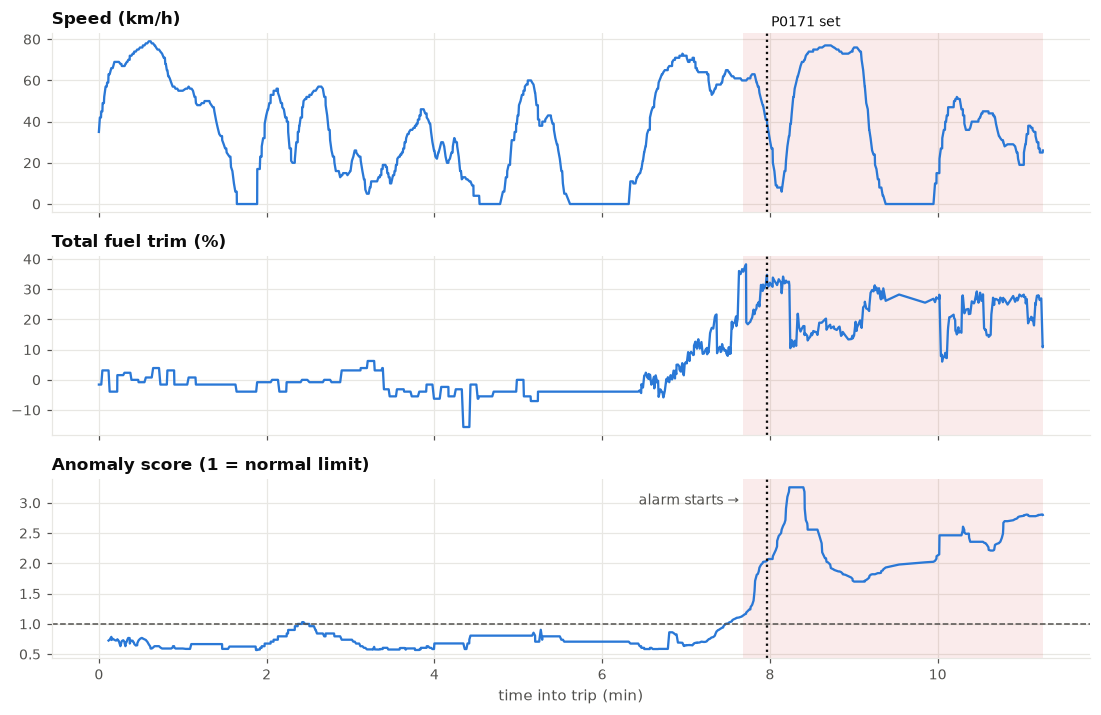

In [4]:
scored = detector.score(logs)
minutes = (scored["time_ms"] - scored["time_ms"].min()) / 60_000
first_alarm = minutes[scored["alarm"]].min()
dtc_min = events["time_ms"].iloc[0] / 60_000

fig, axes = plt.subplots(3, 1, figsize=(10, 6.6), sharex=True)
axes[0].plot(minutes, logs["speed_kmh"], color=BLUE, lw=1.5)
axes[0].set_title("Speed (km/h)", fontsize=11)
axes[1].plot(minutes, logs["stft_b1_pct"] + logs["ltft_b1_pct"], color=BLUE, lw=1.5)
axes[1].set_title("Total fuel trim (%)", fontsize=11)
axes[2].plot(minutes, scored["anomaly_score"].clip(upper=6), color=BLUE, lw=1.5)
axes[2].axhline(1, color=TEXT_2, lw=1, ls="--")
axes[2].set_title("Anomaly score (1 = normal limit)", fontsize=11)
axes[2].set_xlabel("time into trip (min)")
for ax in axes:
    ax.axvspan(first_alarm, minutes.max(), color=FAULT_SHADE, alpha=0.1, lw=0)
    ax.axvline(dtc_min, color=TEXT, lw=1.5, ls=":")
axes[2].text(first_alarm, 0.92, "alarm starts → ", transform=axes[2].get_xaxis_transform(), color=TEXT_2, fontsize=9,
             va="top", ha="right")
axes[0].text(dtc_min, 1.02, " P0171 set", transform=axes[0].get_xaxis_transform(), color=TEXT, fontsize=9, va="bottom")
plt.tight_layout()
print(f"first alarm at {first_alarm:.2f} min, P0171 set at {dtc_min:.2f} min")

The fuel trim climbs from its usual level towards +30%, the anomaly score crosses the limit, and the alarm (shaded) starts before the fault code.

### 2c. Anomaly episodes

Consecutive alarm readings are grouped into episodes, each with the subsystem that scored highest.

In [5]:
episodes = find_episodes(scored)
episodes

,vehicle_id,trip_id,episode,start_ms,end_ms,duration_s,suspect_group,peak_score
0,347,1891,1,461000,675200,214.20,fuel,3.26


### 2d. Root cause from the signals

The evidence is read like a technician reads live data. This step does **not** look at the fault code, so it would work the same before any code is set.

In [6]:
episode = next(episodes.itertuples())
evidence = episode_evidence(scored, episode)
cause = infer_root_cause(evidence, episode.suspect_group, episode.peak_score)

print("evidence (median over the second half of the episode):")
for k, v in evidence.items():
    print(f"  {k:28s} {v:8.2f}" if not np.isnan(v) else f"  {k:28s}      n/a")
print()
print(f"likely cause: {cause.label} ({cause.confidence} confidence)")
for line in cause.evidence:
    print("  -", line)

evidence (median over the second half of the episode):
  total_trim_rel_median           23.11
  maf_residual_median               n/a
  rpm_jitter_steady               32.00
  speed_zero_while_revving         0.00
  speed_jump_rate                  0.08
  hv_voltage_residual_median        n/a
  maf_change_in_trip_pct          -7.03

likely cause: Vacuum leak (high confidence)
  - Fuel trims +23.1% above normal: the ECU is adding fuel (lean)
  - Airflow reading -7% vs earlier in this trip: close to normal, so extra air is entering after the MAF


Fuel trims far above normal mean the engine is running lean. The airflow reading is close to what it was earlier in the trip, so the extra air is entering **after** the MAF sensor: a vacuum leak rather than a dirty MAF. (This vehicle has no learned airflow baseline, so the analyzer compares with the start of the trip instead.)

### 2e. Link the fault code and score the trip

In [7]:
links = link_dtcs(episodes, events)
print(links[["code", "dtc_time_ms", "episode", "warning_before_dtc_s"]].to_string(index=False))
diagnosis = diagnose(scored, events)[0]
print()
print(f"health score: {diagnosis.health_score}/100 -> {diagnosis.status}")
print(f"  100 - {DTC_PENALTY['medium']} (one medium-severity code: P0171) = {100 - DTC_PENALTY['medium']}")

 code  dtc_time_ms  episode  warning_before_dtc_s
P0171       478000        1                 17.00

health score: 75/100 -> needs attention
  100 - 25 (one medium-severity code: P0171) = 75


P0171 is linked to the fuel episode, which started before the code was set: that gap is the early warning. One medium-severity code costs 25 points, which leaves 75: **needs attention**.

## 3. The finished report

The same result from one call, as the command-line tool prints it. The pipeline also writes the report as JSON and as an HTML page with charts.

In [8]:
result = run(log_path, dtc_file=dtc_path, detector=detector)[0]
print(result.text)

════════════════════════════════════════════════════════════════
 VEHICLE DIAGNOSIS REPORT
 Vehicle 347   Trip 1891   2017-11-04 16:28
 11:15 min drive, 6.8 km, 824 readings
════════════════════════════════════════════════════════════════
 HEALTH SCORE:  75 / 100   ⚠ NEEDS ATTENTION

 Fault code(s) P0171 set. Likely cause: Vacuum leak. The problem
   showed in the signals 17 s before the code was set.

 FAULT CODES
  P0171  System Too Lean (Bank 1)
         MEDIUM · set at 7:58
         → Have it checked soon. Performance or emissions may be
           affected.

 ANOMALIES DETECTED
  1. Fuel system (fuel trims)   7:41–11:15   linked to P0171
     detected 17 s BEFORE the fault code
     Likely cause: Vacuum leak (high confidence)
       - Fuel trims +23.1% above normal: the ECU is adding fuel
         (lean)
       - Airflow reading -7% vs earlier in this trip: close to
         normal, so extra air is entering after the MAF

 RECOMMENDED CHECKS
  1. Inspect intake hoses and vacuum li

## 4. All sample trips

In [9]:
rows = []
for log in sorted(SAMPLES.glob("*.csv")):
    if log.stem.endswith("_dtc"):
        continue
    dtc = SAMPLES / f"{log.stem}_dtc.csv"
    r = run(log, dtc_file=dtc if dtc.exists() else None, detector=detector)[0].report
    main = r["main_finding"]
    rows.append({
        "sample": log.stem,
        "health score": r["health"]["score"],
        "status": r["health"]["status"],
        "fault codes": ", ".join(d["code"] for d in r["dtcs"]) or "-",
        "likely cause": main["cause_label"] if main else "-",
        "warning before code (s)": main["warning_before_dtc_s"] if main and main["warning_before_dtc_s"] else np.nan,
    })
samples = pd.DataFrame(rows).set_index("sample").sort_values("health score")
samples

,health score,status,fault codes,likely cause,warning before code (s)
sample,,,,,
misfire,46,critical,P0300,Engine misfire,198.00
hv_battery_degradation,65,needs attention,P0A7F,Hybrid battery degradation,86.60
rich_injector,73,needs attention,P0172,Engine running rich (leaking injector or high fuel pressure),-54.20
maf_drift,75,needs attention,P0101,Dirty or faulty MAF sensor,46.50
vacuum_leak,75,needs attention,P0171,Vacuum leak,17.00
speed_sensor_failure,75,needs attention,P0500,Faulty vehicle speed sensor,42.90
normal_trip,100,good,-,-,NaN


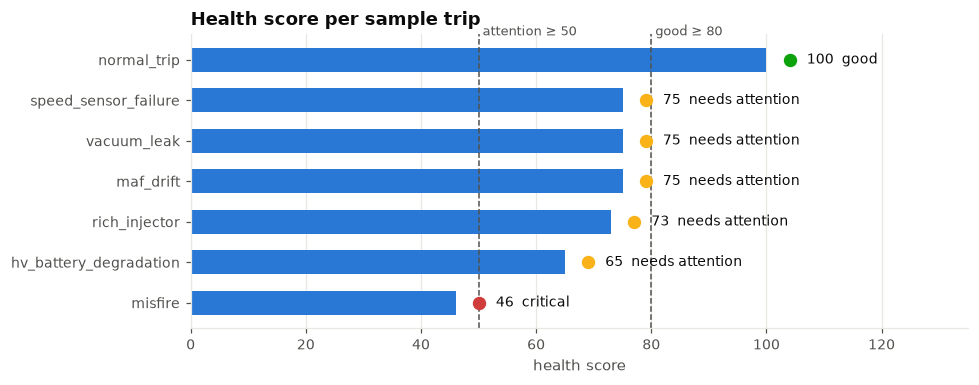

In [10]:
fig, ax = plt.subplots(figsize=(9, 3.6))
y = np.arange(len(samples))
ax.barh(y, samples["health score"], color=BLUE, height=0.6)
ax.set_yticks(y, samples.index)
for i, (score, status) in enumerate(zip(samples["health score"], samples["status"])):
    ax.scatter(score + 4, i, s=60, color=STATUS_COLORS[status], zorder=3)
    ax.text(score + 7, i, f"{score}  {status}", va="center", color=TEXT, fontsize=9)
ax.axvline(80, color=TEXT_2, lw=1, ls="--"); ax.axvline(50, color=TEXT_2, lw=1, ls="--")
ax.text(80, len(samples) - 0.4, " good ≥ 80", color=TEXT_2, fontsize=8.5)
ax.text(50, len(samples) - 0.4, " attention ≥ 50", color=TEXT_2, fontsize=8.5)
ax.set_xlim(0, 135); ax.grid(axis="y", visible=False)
ax.set_xlabel("health score")
ax.set_title("Health score per sample trip")
plt.tight_layout()

The healthy trip scores 100. Each faulty trip is flagged with the right likely cause. The score depends on the fault code's severity (P0300 misfire and P0A7F battery are **high**, the others **medium**), minus extra points for anomalies not explained by a code.

> These samples were picked from trips the model diagnoses correctly, so they show what the output looks like. Section 7 gives the accuracy over all synthetic trips.

## 5. Same trip, different inputs

Fault codes can be given with their time (from a log), without time (read with a scan tool after the drive), or not at all.

In [11]:
variants = {
    "codes file with times": dict(dtc_file=dtc_path),
    "code read after drive (--dtc P0171)": dict(dtc_codes=["P0171"]),
    "no fault codes": dict(),
}
rows = []
for name, kwargs in variants.items():
    r = run(log_path, detector=detector, **kwargs)[0].report
    main = r["main_finding"]
    rows.append({"input": name, "health score": r["health"]["score"], "status": r["health"]["status"],
                 "likely cause": main["cause_label"], "early warning only": main["early_warning"],
                 "warning before code (s)": main["warning_before_dtc_s"], "summary": r["health"]["summary"]})
pd.DataFrame(rows).set_index("input")

,health score,status,likely cause,early warning only,warning before code (s),summary
input,,,,,,
codes file with times,75,needs attention,Vacuum leak,False,17.00,Fault code(s) P0171 set. Likely cause: Vacuum leak. The problem showed in th...
code read after drive (--dtc P0171),75,needs attention,Vacuum leak,False,NaN,Fault code(s) P0171 set. Likely cause: Vacuum leak.
no fault codes,79,needs attention,Vacuum leak,True,NaN,"No fault codes, but 1 early warning(s). Most likely: Vacuum leak. Keep an ey..."


- **With times**, the report shows how early the anomaly appeared.
- **Without times**, the code is still linked to the anomaly, but no warning time is claimed.
- **With no codes at all**, the same anomaly is reported as an **early warning**, with the same likely cause, and the trip still needs attention: a strong, persistent anomaly costs up to 25 points on its own. This is the predictive case: the analyzer flags the problem from the signals alone, before or without any fault code.

## 6. Missing signals

The same trip with only the three required columns. The report says which checks could not run instead of silently skipping them.

In [12]:
with tempfile.TemporaryDirectory() as tmp:
    minimal = Path(tmp) / "minimal.csv"
    raw[["time_ms", "speed_kmh", "engine_rpm"]].to_csv(minimal, index=False)
    r = run(minimal, dtc_file=dtc_path, detector=detector)[0].report
pd.Series(r["checks_run"], name="status").to_frame()

,status
Engine (RPM stability),checked
Vehicle speed sensor,checked
Fuel system (fuel trims),not checked (signals missing in this log)
Air intake (MAF airflow),not checked (signals missing in this log)
Hybrid / EV battery,not checked (signals missing in this log)


In [13]:
print(r["health"]["summary"])

Fault code(s) P0171 set. No matching unusual behaviour in this trip's data.


Without fuel trims the fuel check cannot run, so the analyzer reports the fault code but no matching anomaly, rather than guessing a cause.

## 7. Accuracy at scale

Results over all 240 synthetic trips (120 normal, 120 faulty), from `scripts/evaluate_analysis.py` (needs the VED data):

| Measure | Result |
|---|---|
| Correct root cause (faulty trips where an anomaly was found) | 87% |
| Per fault | misfire 100%, rich 94%, speed 94%, battery 88%, vacuum leak 84%, MAF 65% |
| Normal trips rated good | 98% |
| Faulty trips flagged (needs attention or critical) | 100% |

Every synthetic faulty trip sets a fault code, so flagging them is easy; the root-cause accuracy is the meaningful number. Detection itself is covered in notebook 3.

## 8. Summary

| Step | What happens | Module |
|---|---|---|
| Load and clean | Accepts standard or VED column names; only time, speed and RPM required | `ingestion` |
| Fault codes | List, raw OBD-II response, or CSV with times | `pipeline.collect_dtcs` |
| Score | One detector per subsystem, alarm when the anomaly persists | `detection` |
| Episodes | Alarm periods with a suspect subsystem | `analysis.correlation` |
| Root cause | Rules on the signal evidence, independent of the fault code | `analysis.correlation` |
| Link and score | Fault code ↔ anomaly, warning time, 0–100 health score | `analysis.diagnosis`, `analysis.health_score` |
| Report | Text, JSON and HTML with charts | `reporting` |

```bash
python scripts/run_pipeline.py --log data/samples/vacuum_leak.csv --dtc-file data/samples/vacuum_leak_dtc.csv
```